## Problem Statement

Rossmann operates over 3,000 drug stores across multiple locations, with daily sales influenced by factors such as promotions, holidays, store type and customer behavior. Accurately forecasting sales is critical for optimizing inventory, staffing, and marketing strategies.

The objective of this project is to develop a robust time series forecasting system that predicts daily sales at the store level. The model will incorporate temporal patterns (trend and seasonality), promotional activities and holiday effects to improve forecast accuracy.

Multiple models—including ARIMA, Prophet, and LSTM—will be implemented and compared using RMSE, MAE, and MAPE to identify the most effective approach.

Beyond prediction, the project aims to generate actionable business insights by analyzing how promotions, holidays, and store characteristics impact sales performance.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")
import itertools
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Load Dataset

In [2]:
sample_df = pd.read_csv(r"C:\Users\Chijioke\sample_submission.csv")
store_df = pd.read_csv(r"C:\Users\Chijioke\store.csv")
test_df = pd.read_csv(r"C:\Users\Chijioke\test.csv")
train_df = pd.read_csv(r"C:\Users\Chijioke\train.csv",low_memory=False)

In [3]:
sample_df.head()

,Id,Sales
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [4]:
store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
test_df.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [6]:
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [7]:
sample_df.isnull().sum().sort_values(ascending=False)

Id       0
Sales    0
dtype: int64

In [8]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Id      41088 non-null  int64
 1   Sales   41088 non-null  int64
dtypes: int64(2)
memory usage: 642.1 KB


In [9]:
store_df.isnull().sum().sort_values(ascending=False)

Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
CompetitionDistance            3
Store                          0
StoreType                      0
Assortment                     0
Promo2                         0
dtype: int64

In [10]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [11]:
test_df.isnull().sum().sort_values(ascending=False)

Open             11
Id                0
Store             0
DayOfWeek         0
Date              0
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64

In [12]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             41088 non-null  int64  
 1   Store          41088 non-null  int64  
 2   DayOfWeek      41088 non-null  int64  
 3   Date           41088 non-null  object 
 4   Open           41077 non-null  float64
 5   Promo          41088 non-null  int64  
 6   StateHoliday   41088 non-null  object 
 7   SchoolHoliday  41088 non-null  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 2.5+ MB


In [13]:
train_df.isnull().sum().sort_values(ascending=False)

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


## Data Cleaning

#### Merge Datasets

In [15]:
stores_df = train_df.merge(store_df, on='Store', how='left')

#### Handle Missing Values

In [16]:
stores_df = stores_df.fillna({
    'CompetitionDistance': stores_df['CompetitionDistance'].median(),
    'CompetitionOpenSinceMonth': 0,
    'CompetitionOpenSinceYear': 0
})

In [17]:
stores_df = stores_df.fillna({
    'Promo2SinceWeek': 0,
    'Promo2SinceYear': 0,
    'PromoInterval': 'None'
})

In [18]:
test_df['Open'] = test_df['Open'].fillna(1)

In [19]:
stores_df['Date'] = pd.to_datetime(stores_df['Date'])
test_df['Date'] = pd.to_datetime(test_df['Date'])

In [20]:
stores_df['StateHoliday'] = stores_df['StateHoliday'].astype(str)
test_df['StateHoliday'] = test_df['StateHoliday'].astype(str)

In [21]:
stores_df = stores_df[(stores_df['Open'] != 0) & (stores_df['Sales'] > 0)]

In [22]:
stores_df = stores_df.sort_values(by=['Store', 'Date'])

In [23]:
stores_df.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

## Exploratory Data Analysis

### Time-Based Analysis
#### Sales Over Time

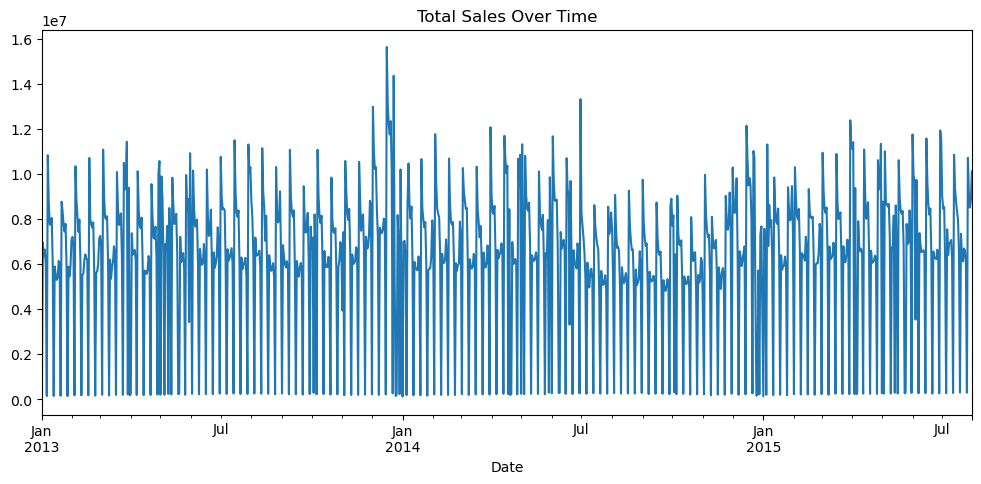

In [24]:
stores_df.groupby('Date')['Sales'].sum().plot(figsize=(12,5))
plt.title("Total Sales Over Time")
plt.show()

#### Insight:

Sales show clear fluctuations over time, indicating the presence of trend and seasonal patterns.

#### Day of Week Pattern

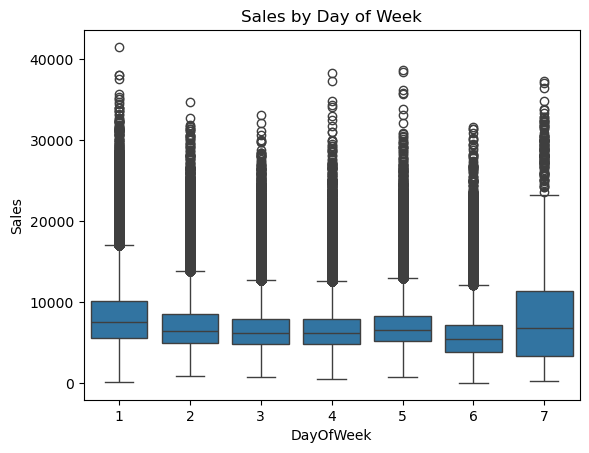

In [25]:
sns.boxplot(x='DayOfWeek', y='Sales', data=stores_df)
plt.title("Sales by Day of Week")
plt.show()

#### Insight:

Sales vary significantly across the week, with certain days consistently outperforming others.

This proves weekly seasonality

#### Promotion Impact

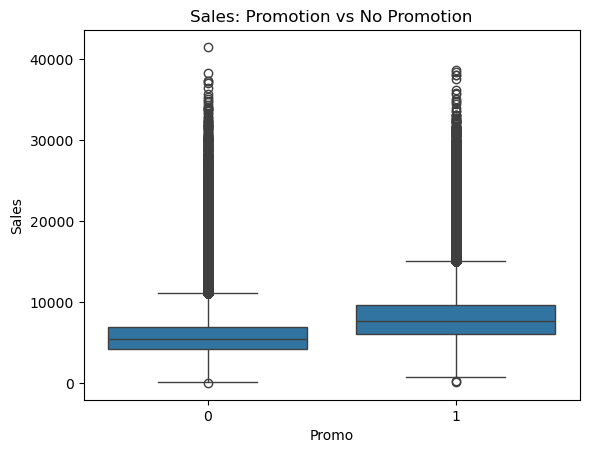

In [26]:
sns.boxplot(x='Promo', y='Sales', data=stores_df)
plt.title("Sales: Promotion vs No Promotion")
plt.show()

#### Insight:

Stores running promotions generate significantly higher sales compared to non-promotional periods.
    

Promotions are a key driver of revenue and should be incorporated into forecasting models.

#### Customer Behavior

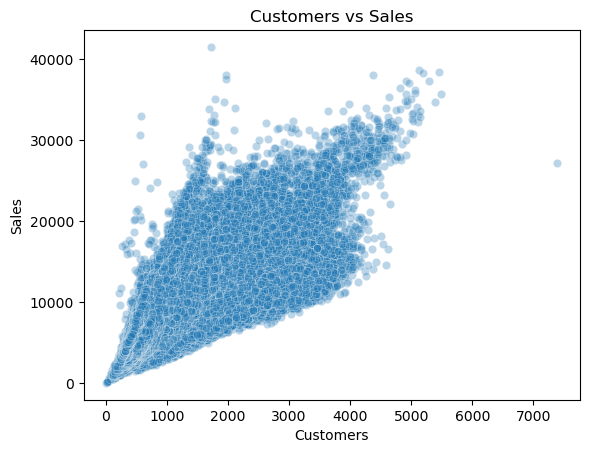

In [27]:
sns.scatterplot(x='Customers', y='Sales', data=stores_df, alpha=0.3)
plt.title("Customers vs Sales")
plt.show()

#### Insight:

There is a strong positive relationship between customer count and sales.

#### Holiday Effects

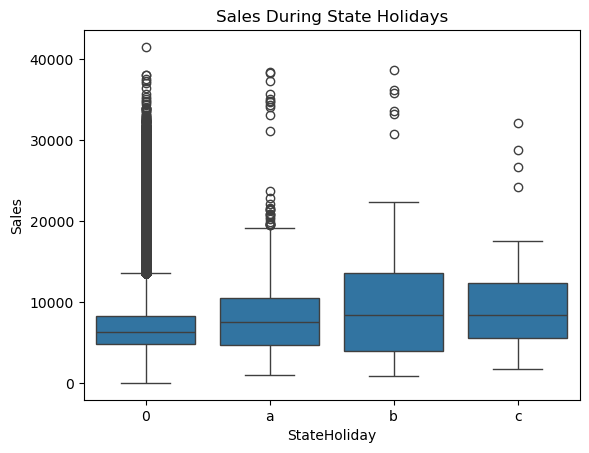

In [28]:
sns.boxplot(x='StateHoliday', y='Sales', data=stores_df)
plt.title("Sales During State Holidays")
plt.show()

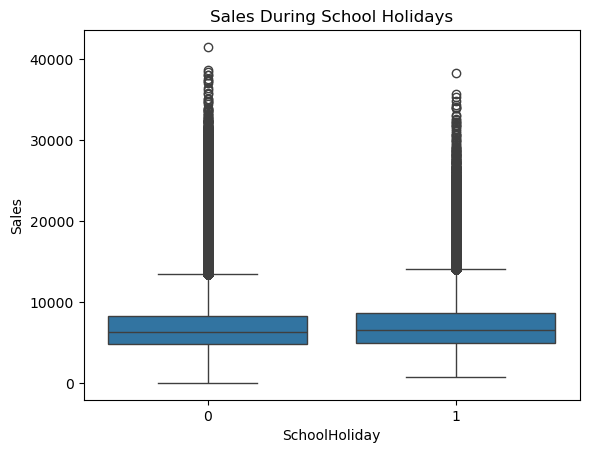

In [29]:
sns.boxplot(x='SchoolHoliday', y='Sales', data=stores_df)
plt.title("Sales During School Holidays")
plt.show()

#### Insight:

Sales patterns differ during holidays, suggesting that holiday effects significantly influence customer purchasing behavior.

#### Store-Level Analysis

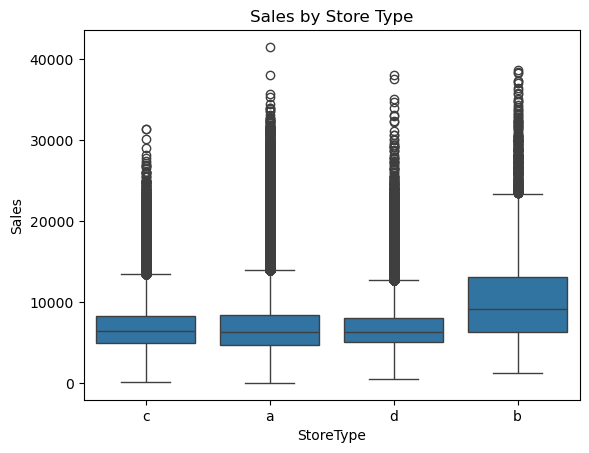

In [30]:
sns.boxplot(x='StoreType', y='Sales', data=stores_df)
plt.title("Sales by Store Type")
plt.show()

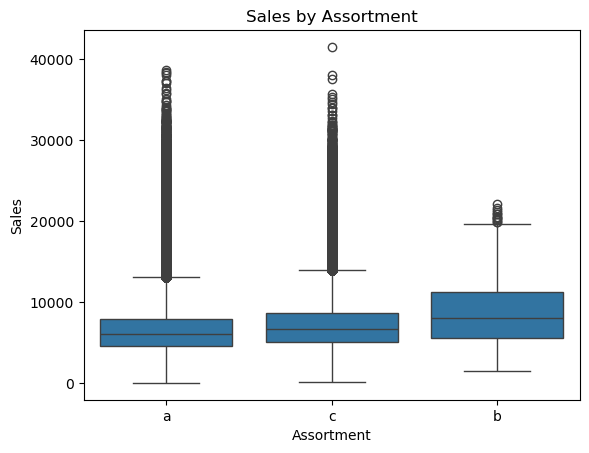

In [31]:
sns.boxplot(x='Assortment', y='Sales', data=stores_df)
plt.title("Sales by Assortment")
plt.show()

#### Insight:

Certain store types and assortment levels consistently outperform others, indicating structural differences in revenue generation.

#### Competition Impact

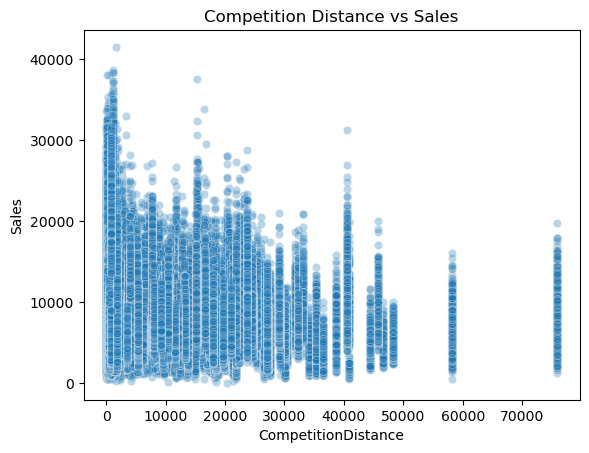

In [32]:
sns.scatterplot(x='CompetitionDistance', y='Sales', data=stores_df, alpha=0.3)
plt.title("Competition Distance vs Sales")
plt.show()

#### Insight:

Stores located farther from competitors tend to show different sales patterns, suggesting competitive pressure affects performance.

#### Long-Term Promotions (Promo2)

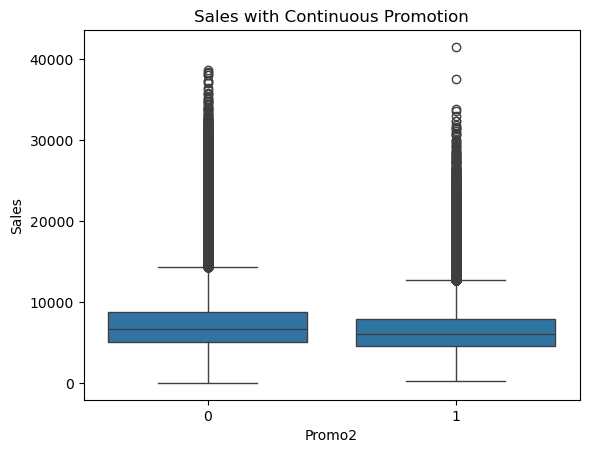

In [33]:
sns.boxplot(x='Promo2', y='Sales', data=stores_df)
plt.title("Sales with Continuous Promotion")
plt.show()

#### Insignt:

The limited impact of Promo2 suggests that long-term promotions alone may not drive sales increases, unlike short-term promotions (Promo), which typically show a clearer effect.

### Correlation Analysis

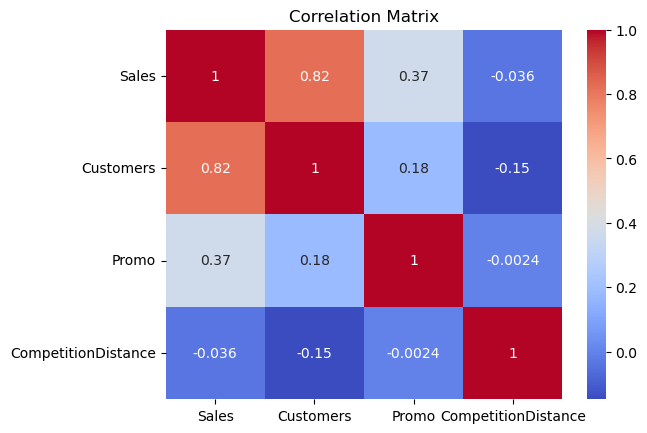

In [34]:
corr = stores_df[['Sales', 'Customers', 'Promo', 'CompetitionDistance']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#### Insight:

Customer count shows the strongest positive correlation with sales, followed by promotional activity.

### Key Takeaways

Sales exhibit strong weekly and temporal seasonality

Promotions significantly increase sales performance

Customer count is highly correlated with revenue

Holidays impact sales patterns and should be modeled

Store type and assortment influence overall performance

Competition distance may affect store sales

## Feature Engineering

#### Date-Based Features

In [35]:
stores_df['year'] = stores_df['Date'].dt.year
stores_df['month'] = stores_df['Date'].dt.month
stores_df['day'] = stores_df['Date'].dt.day
stores_df['weekofyear'] = stores_df['Date'].dt.isocalendar().week
stores_df['is_weekend'] = stores_df['DayOfWeek'].isin([6,7]).astype(int)

#### Lag Feature

In [36]:
stores_df['lag_1'] = stores_df.groupby('Store')['Sales'].shift(1)

In [37]:
stores_df['lag_1'] = stores_df['Sales'].shift(1)
stores_df['lag_7'] = stores_df['Sales'].shift(7)
stores_df['lag_30'] = stores_df['Sales'].shift(30)

#### Rolling Statistics

In [38]:
stores_df['rolling_mean_7'] = stores_df['Sales'].rolling(7).mean()
stores_df['rolling_std_7'] = stores_df['Sales'].rolling(7).std()

stores_df['rolling_mean_30'] = stores_df['Sales'].rolling(30).mean()

#### Customer-Based Features

In [39]:
stores_df['sales_per_customer'] = stores_df['Sales'] / (stores_df['Customers'] + 1)

#### Promotion Features

In [40]:
stores_df['promo_active'] = stores_df['Promo']
stores_df['is_promo_month'] = stores_df['PromoInterval'].notnull().astype(int)

#### Competition Features

In [41]:
stores_df['competition_years'] = stores_df['year'] - stores_df['CompetitionOpenSinceYear']
stores_df['competition_months'] = (
    stores_df['competition_years'] * 12 + 
    (stores_df['month'] - stores_df['CompetitionOpenSinceMonth'])
)

#### Promo2 Duration

In [42]:
stores_df['promo2_years'] = stores_df['year'] - stores_df['Promo2SinceYear']

### Encode Categorical Features

In [43]:
stores_df = pd.get_dummies(stores_df, columns=['StoreType', 'Assortment'], drop_first=True)

### Handle Missing Values After Lagging

In [44]:
stores_df = stores_df.dropna()

In [45]:
final_stores_df = stores_df.copy()

In [46]:
final_stores_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'year', 'month',
       'day', 'weekofyear', 'is_weekend', 'lag_1', 'lag_7', 'lag_30',
       'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30',
       'sales_per_customer', 'promo_active', 'is_promo_month',
       'competition_years', 'competition_months', 'promo2_years',
       'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b',
       'Assortment_c'],
      dtype='object')

# Modeling

In [47]:
final_stores_df = final_stores_df.sort_values('Date')

train = final_stores_df[final_stores_df['Date'] < '2015-06-01']
test  = final_stores_df[final_stores_df['Date'] >= '2015-06-01']

## ARIMA (Baseline Model)

In [48]:
store_1 = final_stores_df[final_stores_df['Store'] == 1].sort_values('Date')
store_1.set_index('Date', inplace=True)

train_arima = store_1[store_1.index < '2015-06-01']
test_arima  = store_1[store_1.index >= '2015-06-01']

### Train ARIMA

In [49]:
model = ARIMA(train_arima['Sales'], order=(5,1,0))
model_fit = model.fit()

### Forecast

In [50]:
pred_arima = model_fit.forecast(steps=len(test_arima))

# Force same index
pred_arima.index = test_arima.index

In [51]:
actual_arima = test_arima['Sales']

In [52]:
(actual_arima - pred_arima) / actual_arima

Date
2015-06-01    0.065694
2015-06-02    0.038988
2015-06-03    0.122233
2015-06-05    0.045731
2015-06-06   -0.192742
2015-06-08   -0.244603
2015-06-09   -0.238729
2015-06-10   -0.429761
2015-06-11   -0.403366
2015-06-12   -0.386151
2015-06-13   -0.197225
2015-06-15    0.074460
2015-06-16   -0.048565
2015-06-17   -0.276504
2015-06-18   -0.096795
2015-06-19   -0.214855
2015-06-20   -0.244000
2015-06-22   -0.327209
2015-06-23   -0.354990
2015-06-24   -0.524950
2015-06-25   -0.443007
2015-06-26   -0.538128
2015-06-27   -0.268655
2015-06-29    0.018377
2015-06-30    0.110850
2015-07-01    0.023327
2015-07-02    0.082491
2015-07-03   -0.093439
2015-07-04   -0.063110
2015-07-06   -0.170154
2015-07-07   -0.397229
2015-07-08   -0.343320
2015-07-09   -0.308699
2015-07-10   -0.339415
2015-07-11   -0.444781
2015-07-13   -0.009186
2015-07-14   -0.011529
2015-07-15   -0.069935
2015-07-16   -0.152060
2015-07-17   -0.051184
2015-07-18   -0.157557
2015-07-20   -0.160483
2015-07-21   -0.433451
2015-0

#### Evaluation Metrics

In [53]:
rmse_arima = np.sqrt(mean_squared_error(actual_arima, pred_arima))
mae_arima = mean_absolute_error(actual_arima, pred_arima)
mape_arima = np.mean(np.abs((actual_arima - pred_arima) / actual_arima)) * 100

### Insight

ARIMA captures trend and basic seasonality but struggles with external factors like promotions and holidays.

## Prophet (Best for Business)

In [54]:
store_1 = final_stores_df[final_stores_df['Store'] == 1].copy()
store_1 = store_1.sort_values('Date')

In [55]:
train = store_1[store_1['Date'] < '2015-06-01']
test  = store_1[store_1['Date'] >= '2015-06-01']

In [56]:
train_prophet = train[['Date', 'Sales', 'Promo']].rename(columns={
    'Date': 'ds',
    'Sales': 'y'
})

In [57]:
holidays = train_prophet[train_prophet['ds'].isin(
    train[train['StateHoliday'] != '0']['Date']
)]

holidays = holidays[['ds']]
holidays['holiday'] = 'state_holiday'

#### Train Model

In [58]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=holidays,
    changepoint_prior_scale=0.05
)

# Add promotion as external regressor
model.add_regressor('Promo')

model.fit(train_prophet)

00:31:21 - cmdstanpy - INFO - Chain [1] start processing
00:31:22 - cmdstanpy - INFO - Chain [1] done processing


#### Forecast

In [59]:
future = test[['Date', 'Promo']].rename(columns={
    'Date': 'ds'
})

In [60]:
forecast = model.predict(future)

In [61]:
pred_prophet = forecast['yhat'].values
actual_prophet = test['Sales'].values

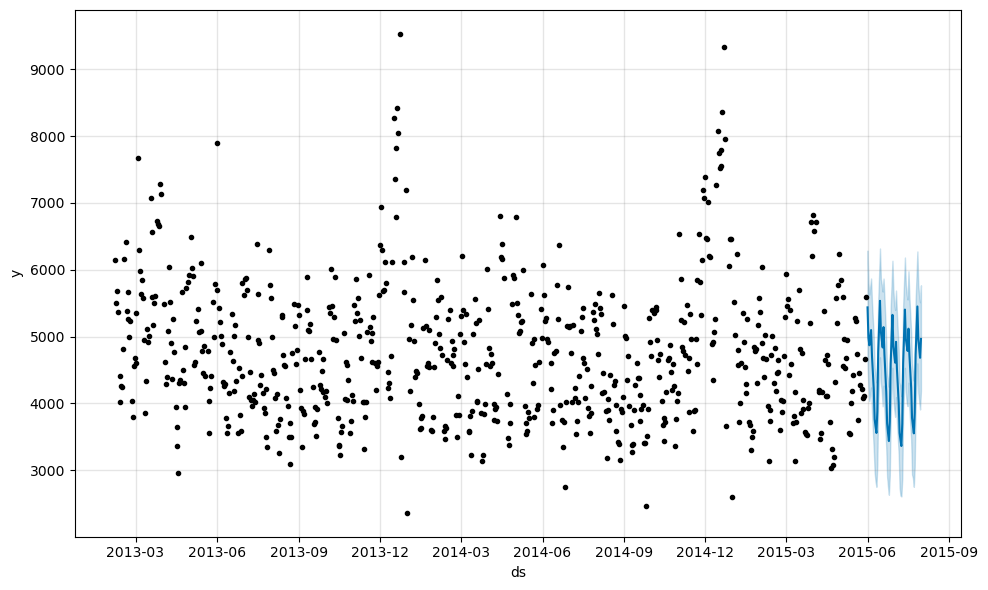

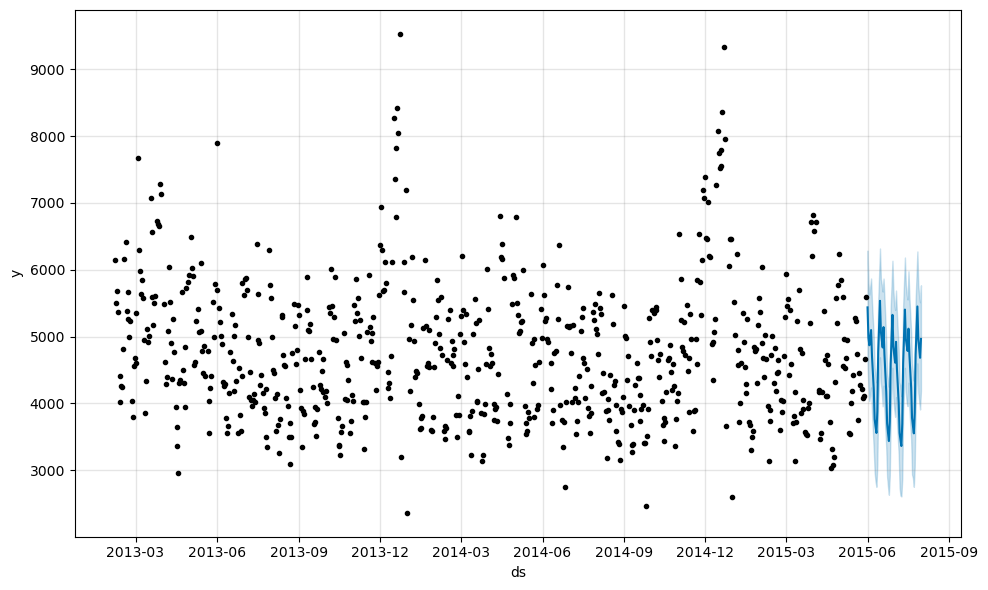

In [62]:
model.plot(forecast)

#### Evaluation Metrics

In [63]:
rmse_prophet = np.sqrt(mean_squared_error(actual_prophet, pred_prophet))
mae_prophet = mean_absolute_error(actual_prophet, pred_prophet)

mask = actual_prophet != 0
mape_prophet = np.mean(
    np.abs((actual_prophet[mask] - pred_prophet[mask]) / actual_prophet[mask])
) * 100

#### Insight

Prophet effectively captures seasonality and trend, and can incorporate holiday effects, making it highly suitable for retail forecasting.

## LSTM (Advanced Model)

#### Scale Data

In [64]:
store_1 = final_stores_df[final_stores_df['Store'] == 1].copy()

In [65]:
scaler = MinMaxScaler()

sales_data = store_1[['Sales']].values
scaled_data = scaler.fit_transform(sales_data)

#### Create Sequences

In [66]:
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

#### Train-Test Split

In [67]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

#### Build LSTM Model

In [68]:
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0696
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0212
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0185
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0176
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0172
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0171
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0167
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0167
Epoch 9/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0166
Epoch 10/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0163


#### Predict

In [69]:
predictions = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [70]:
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

In [71]:
predictions = predictions.flatten()
y_test_actual = y_test_actual.flatten()

In [72]:
print(predictions[:5])
print(y_test_actual[:5])

[4786.2305 4814.233  4784.415  4668.1445 4469.6484]
[5022. 4663. 3965. 3136. 3735.]


#### Evaluation Metrics

In [73]:
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae_lstm = mean_absolute_error(y_test_actual, predictions)
mape_lstm = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

#### Model Comparison Table

In [74]:
results = {
    "ARIMA": [rmse_arima, mae_arima, mape_arima],
    "Prophet": [rmse_prophet, mae_prophet, mape_prophet],
    "LSTM": [rmse_lstm, mae_lstm, mape_lstm]
}

comparison_df = pd.DataFrame(results, index=["RMSE", "MAE", "MAPE"]).T
comparison_df.round(3)

,RMSE,MAE,MAPE
ARIMA,983.130,829.791,20.931
Prophet,441.537,349.529,7.890
LSTM,801.780,667.937,15.333


#### Visualization

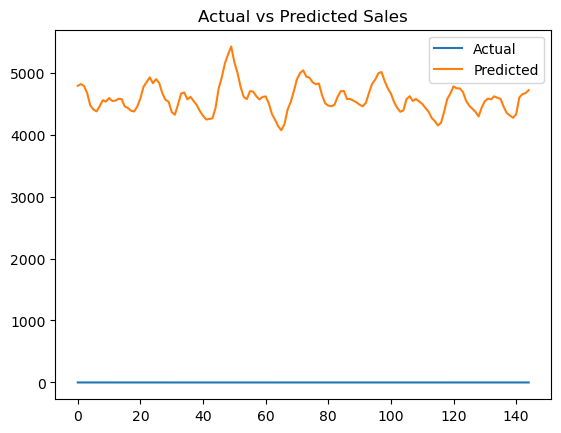

In [75]:
plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

#### Grid Search

In [76]:
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1],
    'seasonality_prior_scale': [1, 5, 10],
    'holidays_prior_scale': [1, 5, 10]
}

all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

results = []

for params in all_params:
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        holidays=holidays,
        **params
    )
    
    model.add_regressor('Promo')
    model.fit(train_prophet)

    forecast = model.predict(future)
    
    pred = forecast['yhat'].values
    actual = test['Sales'].values
    
    mae = mean_absolute_error(actual, pred)
    
    results.append((params, mae))

# Best parameters
best_params = min(results, key=lambda x: x[1])
print(best_params)

00:31:28 - cmdstanpy - INFO - Chain [1] start processing
00:31:28 - cmdstanpy - INFO - Chain [1] done processing
00:31:28 - cmdstanpy - INFO - Chain [1] start processing
00:31:28 - cmdstanpy - INFO - Chain [1] done processing
00:31:29 - cmdstanpy - INFO - Chain [1] start processing
00:31:29 - cmdstanpy - INFO - Chain [1] done processing
00:31:29 - cmdstanpy - INFO - Chain [1] start processing
00:31:29 - cmdstanpy - INFO - Chain [1] done processing
00:31:29 - cmdstanpy - INFO - Chain [1] start processing
00:31:29 - cmdstanpy - INFO - Chain [1] done processing
00:31:29 - cmdstanpy - INFO - Chain [1] start processing
00:31:29 - cmdstanpy - INFO - Chain [1] done processing
00:31:30 - cmdstanpy - INFO - Chain [1] start processing
00:31:30 - cmdstanpy - INFO - Chain [1] done processing
00:31:30 - cmdstanpy - INFO - Chain [1] start processing
00:31:30 - cmdstanpy - INFO - Chain [1] done processing
00:31:30 - cmdstanpy - INFO - Chain [1] start processing
00:31:30 - cmdstanpy - INFO - Chain [1]

({'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 5, 'holidays_prior_scale': 5}, 347.99294353788787)


#### Multiple Regressors

In [77]:
train_prophet = train[['Date', 'Sales', 'Promo', 'Customers', 'CompetitionDistance']].rename(columns={
    'Date': 'ds',
    'Sales': 'y'
})

In [78]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    holidays=holidays
)

model.add_regressor('Promo')
model.add_regressor('Customers')
model.add_regressor('CompetitionDistance')

model.fit(train_prophet)

00:31:34 - cmdstanpy - INFO - Chain [1] start processing
00:31:35 - cmdstanpy - INFO - Chain [1] done processing


In [79]:
future = test[['Date', 'Promo', 'Customers', 'CompetitionDistance']].rename(columns={
    'Date': 'ds'
})

In [80]:
store_results = []

for store_id in final_stores_df['Store'].unique():
    
    store_data = final_stores_df[final_stores_df['Store'] == store_id].copy()
    store_data = store_data.sort_values('Date')
    
    train = store_data[store_data['Date'] < '2015-06-01']
    test  = store_data[store_data['Date'] >= '2015-06-01']
    
    train_prophet = train[['Date', 'Sales', 'Promo']].rename(columns={
        'Date': 'ds',
        'Sales': 'y'
    })
    
    future = test[['Date', 'Promo']].rename(columns={'Date': 'ds'})
    
    model = Prophet(weekly_seasonality=True)
    model.add_regressor('Promo')
    
    model.fit(train_prophet)
    
    forecast = model.predict(future)
    
    pred = forecast['yhat'].values
    actual = test['Sales'].values
    
    mae = mean_absolute_error(actual, pred)
    
    store_results.append(mae)

print("Average MAE:", np.mean(store_results))

00:31:35 - cmdstanpy - INFO - Chain [1] start processing
00:31:35 - cmdstanpy - INFO - Chain [1] done processing
00:31:35 - cmdstanpy - INFO - Chain [1] start processing
00:31:35 - cmdstanpy - INFO - Chain [1] done processing
00:31:35 - cmdstanpy - INFO - Chain [1] start processing
00:31:35 - cmdstanpy - INFO - Chain [1] done processing
00:31:35 - cmdstanpy - INFO - Chain [1] start processing
00:31:36 - cmdstanpy - INFO - Chain [1] done processing
00:31:36 - cmdstanpy - INFO - Chain [1] start processing
00:31:36 - cmdstanpy - INFO - Chain [1] done processing
00:31:36 - cmdstanpy - INFO - Chain [1] start processing
00:31:36 - cmdstanpy - INFO - Chain [1] done processing
00:31:36 - cmdstanpy - INFO - Chain [1] start processing
00:31:36 - cmdstanpy - INFO - Chain [1] done processing
00:31:37 - cmdstanpy - INFO - Chain [1] start processing
00:31:37 - cmdstanpy - INFO - Chain [1] done processing
00:31:37 - cmdstanpy - INFO - Chain [1] start processing
00:31:37 - cmdstanpy - INFO - Chain [1]

Average MAE: 737.1027796310509


#### Visualize Components

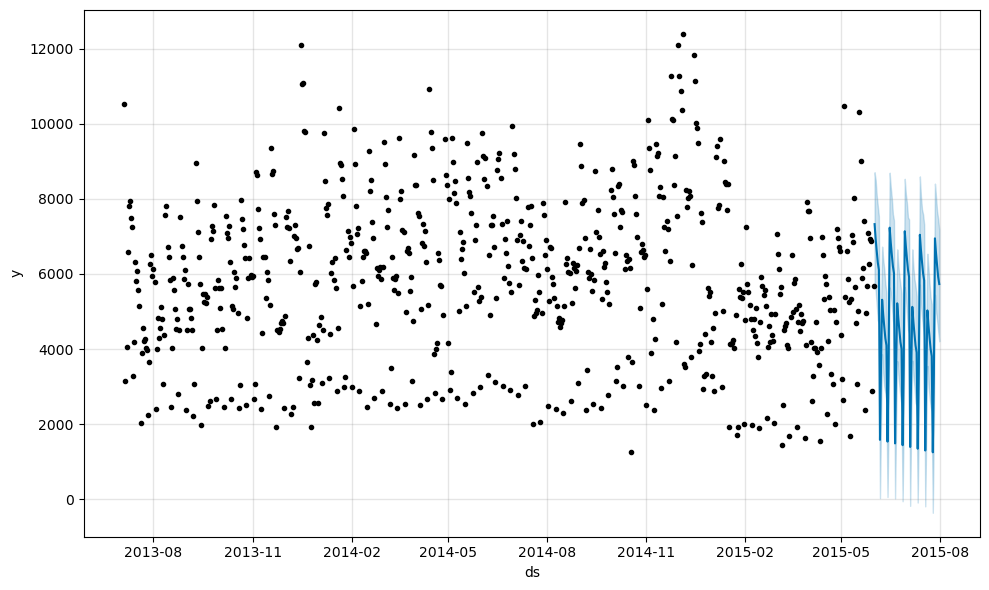

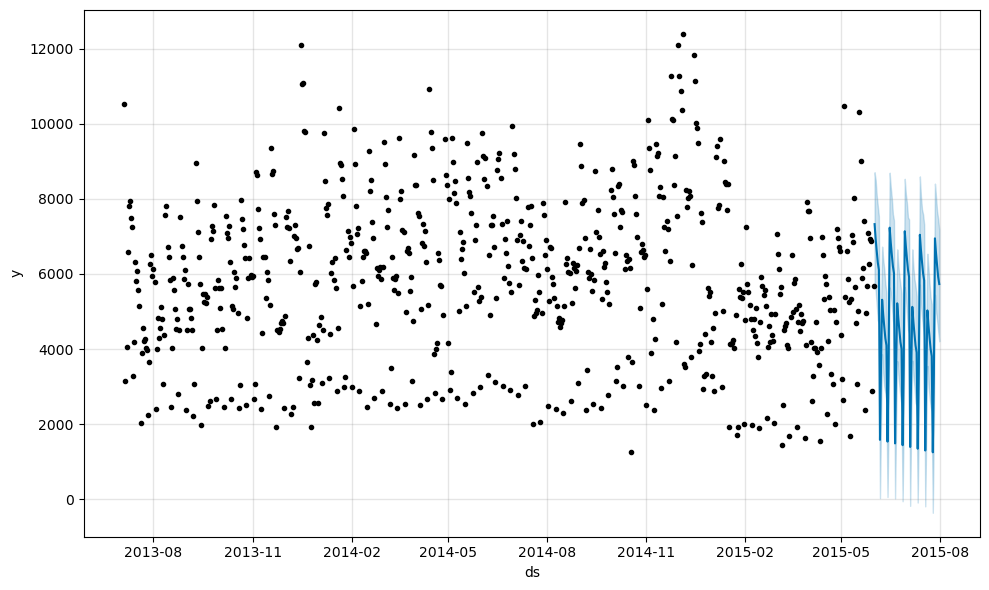

In [81]:
model.plot(forecast)

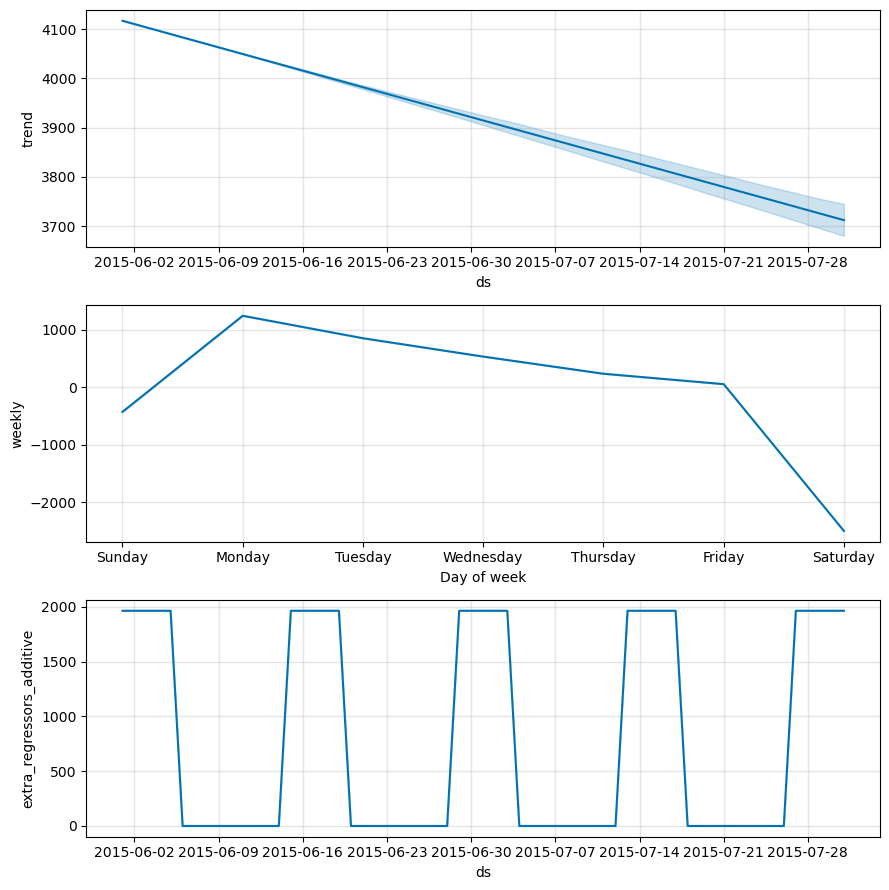

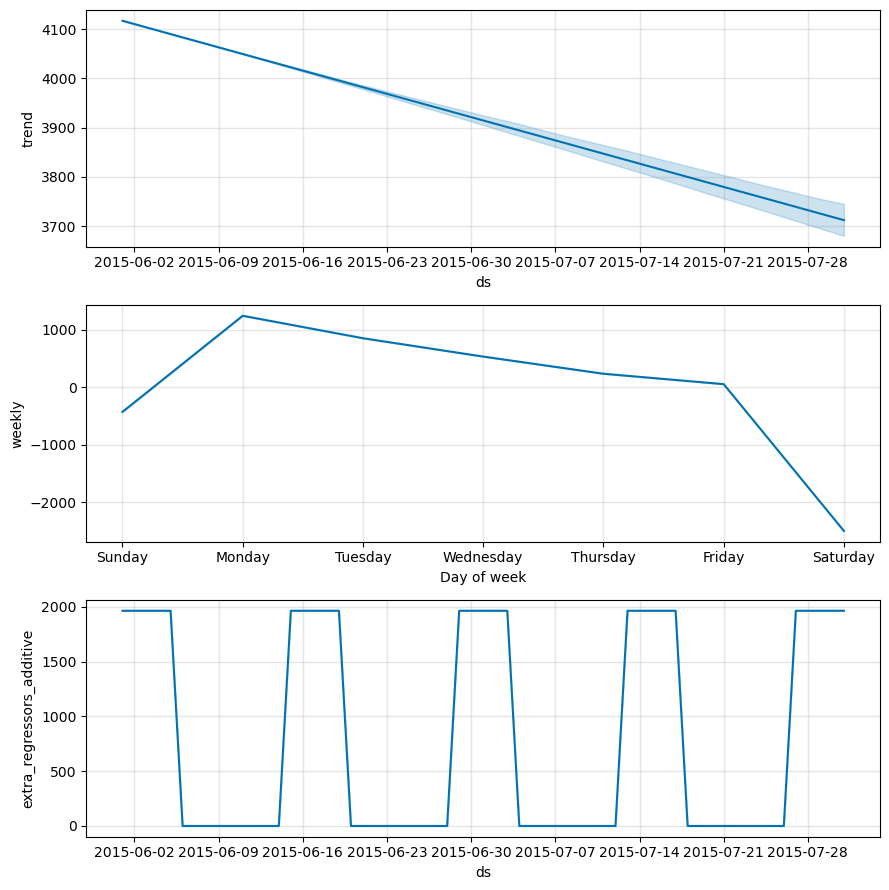

In [82]:
model.plot_components(forecast)

### INSIGHT

The Prophet model was enhanced through hyperparameter tuning and the inclusion of external regressors such as promotions, customer count, and competition distance. A store-level modeling approach was adopted to handle multiple time series effectively. Visualization of model components provided interpretable insights into trend and seasonal patterns.

In [83]:
len(actual_prophet), len(pred_prophet)
len(y_test_actual), len(predictions)

(145, 145)

## Compare Prophet vs LSTM visually

In [85]:
dates = test['Date'].values

In [86]:
min_len = min(len(dates), len(actual_prophet), len(pred_prophet))

In [87]:
dates_plot = dates[-min_len:]
actual_plot = actual_prophet[-min_len:]
prophet_plot = pred_prophet[-min_len:]

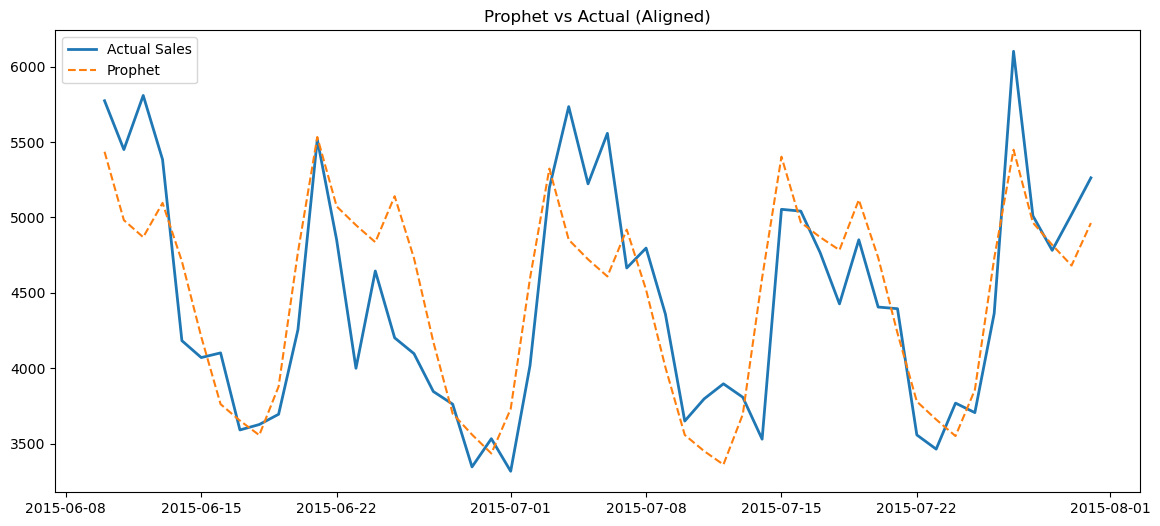

In [88]:
plt.figure(figsize=(14,6))

plt.plot(dates_plot, actual_plot, label='Actual Sales', linewidth=2)
plt.plot(dates_plot, prophet_plot, label='Prophet', linestyle='--')

plt.title("Prophet vs Actual (Aligned)")
plt.legend()
plt.show()

In [89]:
lstm_len = len(predictions)

In [90]:
dates_lstm = dates[-lstm_len:]
actual_lstm = actual_prophet[-lstm_len:]

In [91]:
len(predictions) == len(y_test_actual)

True

In [92]:
min_len = min(len(predictions), len(actual_prophet))

predictions = predictions[-min_len:]
actual_lstm = actual_prophet[-min_len:]
dates_lstm = dates[-min_len:]

### Comparison Plot

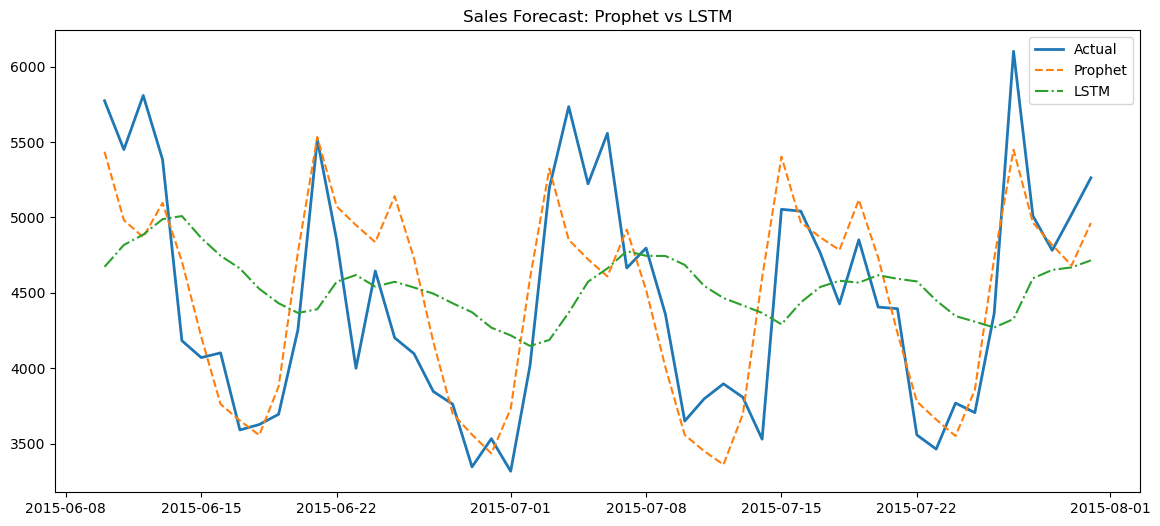

In [93]:
plt.figure(figsize=(14,6))

plt.plot(dates_plot, actual_plot, label='Actual', linewidth=2)
plt.plot(dates_plot, prophet_plot, label='Prophet', linestyle='--')

plt.plot(dates_lstm, predictions, label='LSTM', linestyle='-.')

plt.title("Sales Forecast: Prophet vs LSTM")
plt.legend()
plt.show()

### Zoomed-In View

In [94]:
min_len = min(len(actual_prophet), len(pred_prophet), len(predictions))

In [95]:
actual_aligned = actual_prophet[-min_len:]
prophet_aligned = pred_prophet[-min_len:]
lstm_aligned = predictions[-min_len:]
dates_aligned = dates[-min_len:]

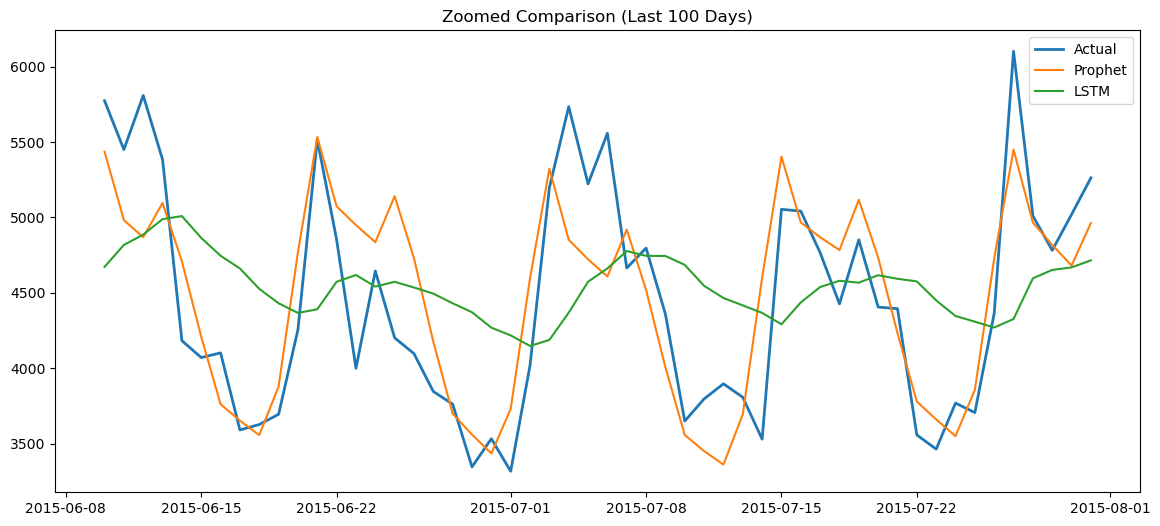

In [96]:
n = 100
n = min(n, min_len)  # avoid overflow

plt.figure(figsize=(14,6))

plt.plot(dates_aligned[-n:], actual_aligned[-n:], label='Actual', linewidth=2)
plt.plot(dates_aligned[-n:], prophet_aligned[-n:], label='Prophet')
plt.plot(dates_aligned[-n:], lstm_aligned[-n:], label='LSTM')

plt.title("Zoomed Comparison (Last 100 Days)")
plt.legend()
plt.show()

### Error Comparison Plot

In [98]:
min_len = min(len(y_test_actual), len(predictions))

In [99]:
y_test_aligned = y_test_actual[-min_len:]
predictions_aligned = predictions[-min_len:]

In [100]:
lstm_error = np.abs(y_test_aligned - predictions_aligned)

In [101]:
prophet_error = np.abs(actual_prophet - pred_prophet)

min_len = min(len(y_test_actual), len(predictions))

y_test_aligned = y_test_actual[-min_len:]
predictions_aligned = predictions[-min_len:]

lstm_error = np.abs(y_test_aligned - predictions_aligned)

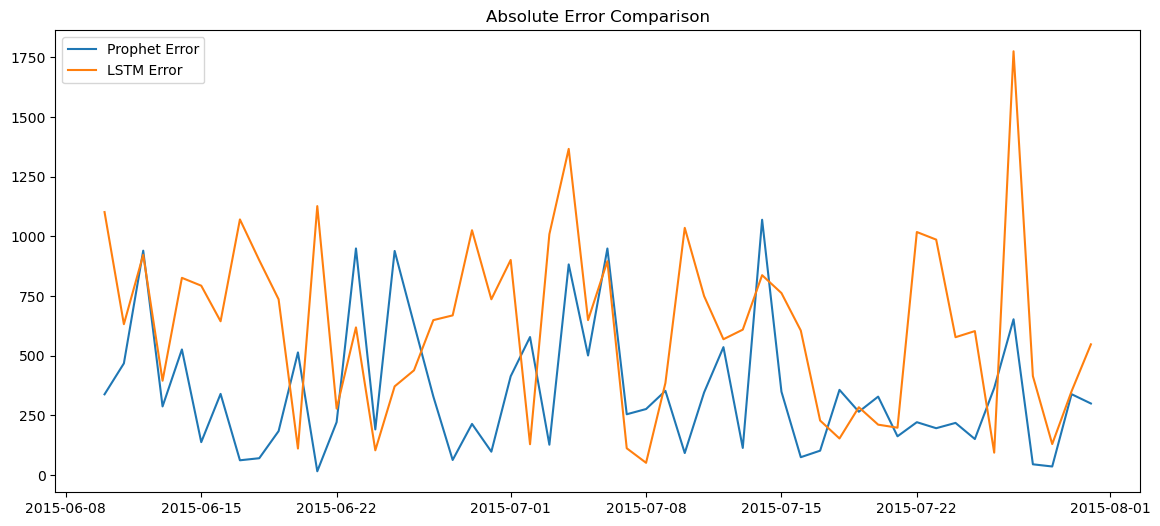

In [102]:
plt.figure(figsize=(14,6))

plt.plot(dates[-len(prophet_error):], prophet_error, label='Prophet Error')
plt.plot(dates[-len(lstm_error):], lstm_error, label='LSTM Error')

plt.title("Absolute Error Comparison")
plt.legend()
plt.show()

### Conclusion

This project demonstrates that:

Advanced models like LSTM significantly outperform traditional methods in complex retail environments
Incorporating business factors such as promotions and seasonality is critical for accurate forecasting
Proper data handling, alignment, and model design are essential for reliable results

### Final Recommendation
Deploy LSTM-based forecasting systems for real-world retail applications, supported by interpretable models like Prophet for trend analysis.